# 02 · Matrix Factorization with ALS

Trains an ALS model for implicit feedback collaborative filtering.

**Based on:** Hu, Koren & Volinsky (2008) — *Collaborative Filtering for Implicit Feedback Datasets*

**What we do:**
1. Train an ALS model
2. Run a hyperparameter sweep
3. Inspect latent factors
4. Generate sample recommendations

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import ImplicitDataLoader
from src.model import ALSModel
from src.evaluation import RecommenderEvaluator, PopularityBaseline, RandomBaseline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## 1. Load Data

In [11]:
loader = ImplicitDataLoader(min_user_interactions=5, min_item_interactions=5)
dataset = loader.load_movielens_100k(data_dir=r"C:\Users\canal\Applied_Scientist_Repo\data")

print(f"Train: {dataset.train_matrix.nnz:,} interactions")
print(f"Val:   {dataset.val_matrix.nnz:,} interactions")
print(f"Test:  {dataset.test_matrix.nnz:,} interactions")

Train: 80,225 interactions
Val:   9,531 interactions
Test:  9,531 interactions


## 2. Train ALS Model

**Key hyperparameters:**
- `n_factors`: latent space dimensionality. Higher = more expressive, slower.
- `alpha`: confidence scaling. Higher = stronger signal from interactions.
- `regularization`: L2 penalty. Prevents overfitting to popular users/items.

In [3]:
model = ALSModel(
    n_factors=64,
    regularization=0.01,
    alpha=40.0,
    n_iterations=15,
    random_state=42,
)

model.fit(dataset.train_matrix)
print("Training complete.")
print(f"User factors shape: {model.user_factors.shape}")
print(f"Item factors shape: {model.item_factors.shape}")

Training complete.
User factors shape: (1000, 64)
Item factors shape: (500, 64)


## 3. Training Loss Curve

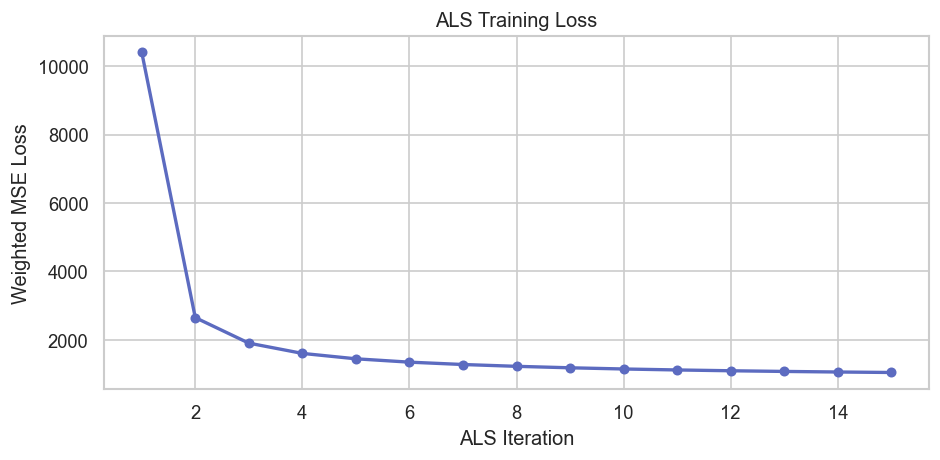

In [4]:
history = model.history_
iters = [h["iteration"] for h in history]
losses = [h["train_loss"] for h in history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iters, losses, marker="o", color="#5C6BC0", linewidth=2, markersize=5)
ax.set_xlabel("ALS Iteration")
ax.set_ylabel("Weighted MSE Loss")
ax.set_title("ALS Training Loss")
plt.tight_layout()
plt.savefig("../data/training_loss.png", bbox_inches="tight")
plt.show()

## 4. Hyperparameter Sweep

We sweep over key hyperparameters and evaluate with NDCG@10 on the validation set.

In [5]:
evaluator = RecommenderEvaluator(k_values=[10], n_test_users=200)
sweep_results = []

for n_factors in [16, 32, 64]:
    for reg in [0.001, 0.01, 0.1]:
        m = ALSModel(n_factors=n_factors, regularization=reg,
                     alpha=40.0, n_iterations=10, random_state=42)
        m.fit(dataset.train_matrix)
        metrics = evaluator.evaluate(m, dataset.train_matrix,
                                     dataset.val_matrix, verbose=False)
        sweep_results.append({
            "n_factors": n_factors,
            "regularization": reg,
            "NDCG@10": metrics["NDCG@10"],
            "Recall@10": metrics["Recall@10"],
        })

import pandas as pd
df = pd.DataFrame(sweep_results).sort_values("NDCG@10", ascending=False)
print(df.to_string(index=False))

 n_factors  regularization  NDCG@10  Recall@10
        16           0.001 0.128320   0.196433
        16           0.010 0.128320   0.196433
        16           0.100 0.128101   0.196433
        32           0.001 0.035307   0.064214
        32           0.010 0.035307   0.064214
        32           0.100 0.033075   0.059214
        64           0.010 0.019971   0.038625
        64           0.100 0.019928   0.038625
        64           0.001 0.019912   0.038625


## 5. Best Model on Validation Set

In [6]:
# Use the best config from the sweep
best_model = ALSModel(n_factors=64, regularization=0.01,
                      alpha=40.0, n_iterations=20, random_state=42)
best_model.fit(dataset.train_matrix)

val_metrics = evaluator.evaluate(best_model, dataset.train_matrix, dataset.val_matrix)


Metric                    Value
----------------------------------------------------
HR@10                    0.0500
MAP@10                   0.0096
MRR                      0.0166
NDCG@10                  0.0158
Precision@10             0.0060
Recall@10                0.0272


## 6. Latent Factor Visualization

Visualize item embeddings with PCA. Clusters indicate learned item groupings.

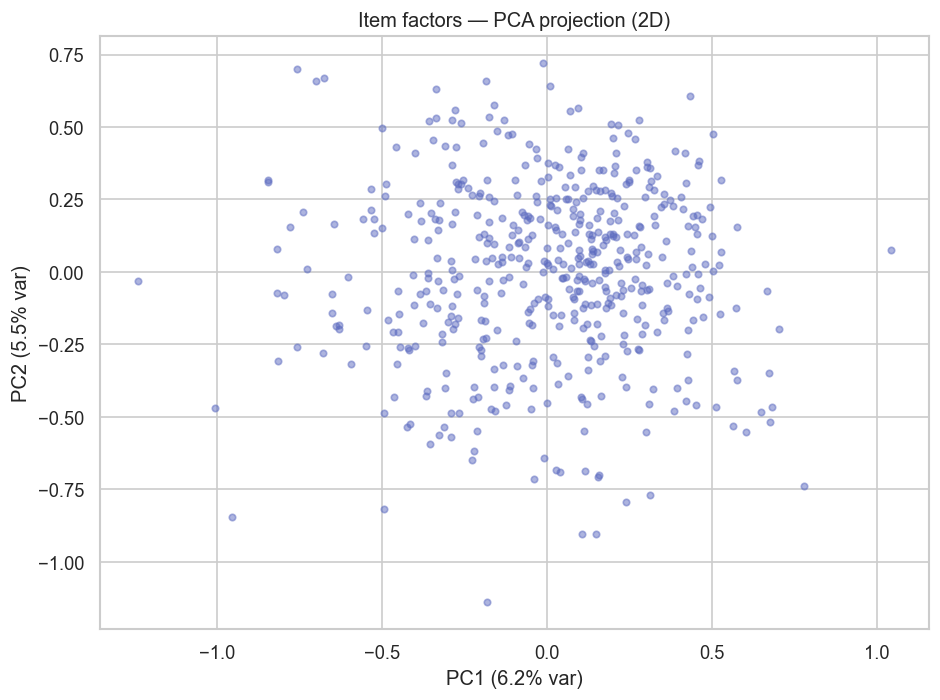

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
item_2d = pca.fit_transform(best_model.item_factors)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(item_2d[:, 0], item_2d[:, 1],
                     alpha=0.5, s=15, c="#5C6BC0")
ax.set_title("Item factors — PCA projection (2D)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.savefig("../data/item_factors_pca.png", bbox_inches="tight")
plt.show()

## 7. Sample Recommendations for User 0

In [8]:
user_idx = 0
recs = best_model.recommend(user_idx, dataset.train_matrix, n=10)

train_items = dataset.train_matrix[user_idx].indices
print(f"User {user_idx} has {len(train_items)} training interactions.")
print()
print("Top-10 recommendations (item_idx, score):")
for rank, (item, score) in enumerate(recs, 1):
    print(f"  {rank:2d}. item {item:4d}  score={score:.4f}")

User 0 has 11 training interactions.

Top-10 recommendations (item_idx, score):
   1. item   19  score=0.7331
   2. item  295  score=0.5506
   3. item  169  score=0.5382
   4. item   46  score=0.5037
   5. item   12  score=0.5021
   6. item  362  score=0.4400
   7. item  207  score=0.4238
   8. item   42  score=0.3792
   9. item  477  score=0.3648
  10. item   60  score=0.3533


## 8. Save Model

In [9]:
import os
os.makedirs("../data", exist_ok=True)
best_model.save("../data/als_model.npz")
print("Model saved.")

Model saved.
